In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
df = pd.read_csv("qaps.csv")

df.head()

,document_id,set,question,answer1,answer2,question_tokenized,answer1_tokenized,answer2_tokenized
0,0025577043f5090cd603c6aea60f26e236195594,test,Who is Mark Hunter?,He is a high school student in Phoenix.,A loner and outsider student with a radio stat...,Who is Mark Hunter ?,He is a high school student in Phoenix .,A loner and outsider student with a radio stat...
1,0025577043f5090cd603c6aea60f26e236195594,test,Where does this radio station take place?,It takes place in Mark's parents basement.,"Phoenix, Arizona",Where does this radio station take place ?,It takes place in Mark s parents basement .,"Phoenix , Arizona"
2,0025577043f5090cd603c6aea60f26e236195594,test,Why do more students tune into Mark's show?,Mark talks about what goes on at school and in...,Because he has a thing to say about what is ha...,Why do more students tune into Mark s show ?,Mark talks about what goes on at school and in...,Because he has a thing to say about what is ha...
3,0025577043f5090cd603c6aea60f26e236195594,test,Who commits suicide?,Malcolm.,Malcolm.,Who commits suicide ?,Malcolm .,Malcolm .
4,0025577043f5090cd603c6aea60f26e236195594,test,What does Paige jam into her microwave?,She jams her medals and accolades.,Her award medals,What does Paige jam into her microwave ?,She jams her medals and accolades .,Her award medals


In [4]:
if "answer" in df.columns:
    df["text"] = df["question"].astype(str) + " " + df["answer"].astype(str)
else:
    df["text"] = df["question"].astype(str)

In [5]:
stop_words = stopwords.words('english')

vectorizer = TfidfVectorizer(
    stop_words=stop_words,
    max_features=5000,
    lowercase=True
)

X = vectorizer.fit_transform(df["text"])
print(X.shape)

(46759, 5000)


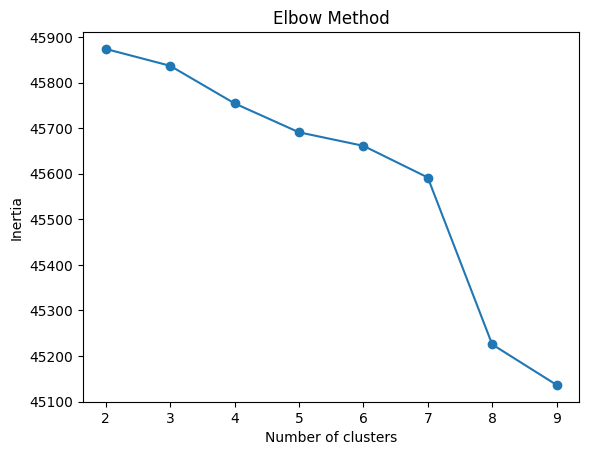

In [6]:
inertia = []
K_range = range(2, 10)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

In [7]:
k = 5  # change based on elbow result

kmeans = KMeans(n_clusters=k, random_state=42)
df["cluster"] = kmeans.fit_predict(X)

df.head()

,document_id,set,question,answer1,answer2,question_tokenized,answer1_tokenized,answer2_tokenized,text,cluster
0,0025577043f5090cd603c6aea60f26e236195594,test,Who is Mark Hunter?,He is a high school student in Phoenix.,A loner and outsider student with a radio stat...,Who is Mark Hunter ?,He is a high school student in Phoenix .,A loner and outsider student with a radio stat...,Who is Mark Hunter?,4
1,0025577043f5090cd603c6aea60f26e236195594,test,Where does this radio station take place?,It takes place in Mark's parents basement.,"Phoenix, Arizona",Where does this radio station take place ?,It takes place in Mark s parents basement .,"Phoenix , Arizona",Where does this radio station take place?,4
2,0025577043f5090cd603c6aea60f26e236195594,test,Why do more students tune into Mark's show?,Mark talks about what goes on at school and in...,Because he has a thing to say about what is ha...,Why do more students tune into Mark s show ?,Mark talks about what goes on at school and in...,Because he has a thing to say about what is ha...,Why do more students tune into Mark's show?,4
3,0025577043f5090cd603c6aea60f26e236195594,test,Who commits suicide?,Malcolm.,Malcolm.,Who commits suicide ?,Malcolm .,Malcolm .,Who commits suicide?,4
4,0025577043f5090cd603c6aea60f26e236195594,test,What does Paige jam into her microwave?,She jams her medals and accolades.,Her award medals,What does Paige jam into her microwave ?,She jams her medals and accolades .,Her award medals,What does Paige jam into her microwave?,4


In [8]:
terms = vectorizer.get_feature_names_out()

def get_top_terms(cluster_center, n=10):
    return [terms[i] for i in cluster_center.argsort()[-n:]]

for i, center in enumerate(kmeans.cluster_centers_):
    print(f"\nCluster {i}")
    print(get_top_terms(center))


Cluster 0
['antagonist', 'love', 'first', 'end', 'protagonist', 'name', 'characters', 'story', 'main', 'character']

Cluster 1
['take', 'metro', 'get', 'kill', 'ship', 'old', 'name', 'captain', 'man', 'plan']

Cluster 2
['king', 'conrad', 'anna', 'pierre', 'story', 'kind', 'mr', 'end', 'romantic', 'relationship']

Cluster 3
['groups', 'women', 'main', 'things', 'story', 'people', 'characters', 'names', 'men', 'two']

Cluster 4
['find', 'many', 'get', 'father', 'take', 'end', 'die', 'happens', 'name', 'story']


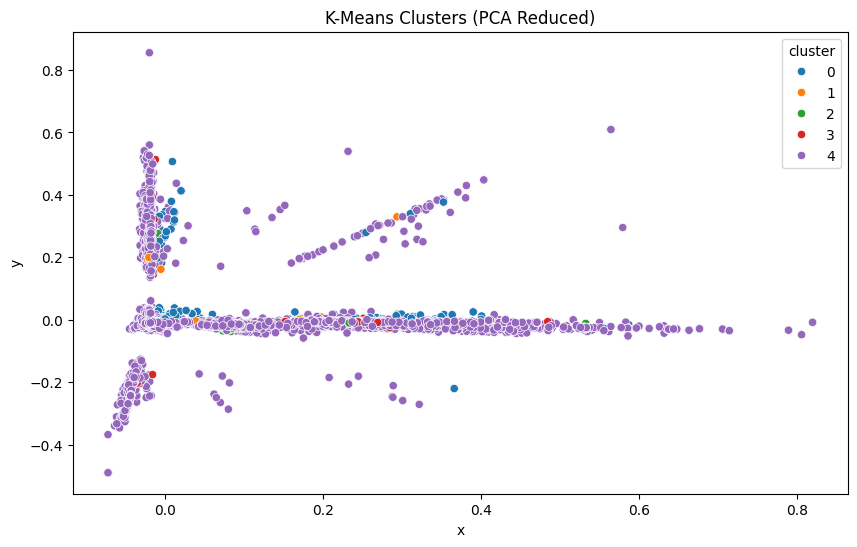

In [9]:
pca = PCA(n_components=2)
reduced = pca.fit_transform(X.toarray())

df["x"] = reduced[:, 0]
df["y"] = reduced[:, 1]

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="x", y="y", hue="cluster", palette="tab10")
plt.title("K-Means Clusters (PCA Reduced)")
plt.show()

In [10]:
for i in range(k):
    print(f"\n===== CLUSTER {i} =====")
    print(df[df["cluster"] == i]["text"].head(3).values)


===== CLUSTER 0 =====
<ArrowStringArray>
['What was the main focus at the beginning of the trip?',
       'Maskull learns that he is also what character? ',
                            'Who is the main character?']
Length: 3, dtype: str

===== CLUSTER 1 =====
<ArrowStringArray>
[                  'How does Percival save Captain Delmar's life?',
 'Who's lives does Percival convince the pirate captain to spare?',
                             'Who was Dr. Ferguson's man servant?']
Length: 3, dtype: str

===== CLUSTER 2 =====
<ArrowStringArray>
['Who does Annie have a relationship with in the beginning of the story?',
 'What kind of relationship do Crash and Ebby have when they first meet?',
                               'What is Jacob's relationship to Lisbeth?']
Length: 3, dtype: str

===== CLUSTER 3 =====
<ArrowStringArray>
[                                         'Which two societies are aligned in this play?',
                                      'What does Shinzon do to the two R